In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score

In [2]:
# DATASET - 1
df1 = pd.read_csv("cardio_train_separated.csv")
df1.head()
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
# MISSING VALUES FILLING
df1.isnull().sum()
df1 = df1.fillna(df1.mean(numeric_only=True))
# LABEL ENCODING
le = LabelEncoder()

for col in df1.columns:
    if df1[col].dtype == 'object':
        df1[col] = le.fit_transform(df1[col])

In [4]:
# FEATURES TARGET
X1 = df1.drop(['cardio','id'], axis=1)
y1 = df1['cardio']
# FEATURES SCALING - STANDARDIZATION
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
# TRAIN(80%) - TEST(20%) SPLIT
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_scaled, y1, test_size=0.2, random_state=42
)

In [5]:
# LOGISTIC REGRESSION FOR DATASET - 1
lr1 = LogisticRegression(max_iter=5000)

lr1.fit(X1_train, y1_train)

y_pred_lr1 = lr1.predict(X1_test)

print("Logistic Regression Accuracy:", accuracy_score(y1_test, y_pred_lr1))
print("Logistic Regression Precision:", precision_score(y1_test, y_pred_lr1))
# CROSS VALIDATION SCORE
cv_lr1 = cross_val_score(lr1, X1_scaled, y1, cv=5)
print("Logistic Regression CV Score:", cv_lr1.mean())

Logistic Regression Accuracy: 0.7236428571428571
Logistic Regression Precision: 0.7458157359612075
Logistic Regression CV Score: 0.7202857142857144


In [6]:
# SUPPORT VECTOR MACHINE FOR DATASET - 1
svm1 = LinearSVC(max_iter=5000)

svm1.fit(X1_train, y1_train)

y_pred_svm1 = svm1.predict(X1_test)

print("SVM Accuracy:", accuracy_score(y1_test, y_pred_svm1))
print("SVM Precision:", precision_score(y1_test, y_pred_svm1))
# CROSS VALIDATION SCORE
cv_svm1 = cross_val_score(svm1, X1_train, y1_train, cv=3, n_jobs=-1)

print("SVM CV Score:", cv_svm1.mean())

SVM Accuracy: 0.6562142857142857
SVM Precision: 0.668247895944912
SVM CV Score: 0.6500000058355634


In [7]:
# RANDOM FOREST FOR DATASET - 1
rf1 = RandomForestClassifier(n_estimators=100, random_state=42)

rf1.fit(X1_train, y1_train)

y_pred_rf1 = rf1.predict(X1_test)

print("Random Forest Accuracy:", accuracy_score(y1_test, y_pred_rf1))
print("Random Forest Precision:", precision_score(y1_test, y_pred_rf1))
# CROSS VALIDATION SCORE
cv_rf1 = cross_val_score(rf1, X1_scaled, y1, cv=5)
print("Random Forest CV Score:", cv_rf1.mean())

Random Forest Accuracy: 0.7140714285714286
Random Forest Precision: 0.7190913062472696
Random Forest CV Score: 0.7150857142857143


In [8]:
# DATASET - 2
df2 = pd.read_csv("HeartDiseaseTrain-Test.csv")
df2.head()
df2.info()
df2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [9]:
# MISSING VALUES FILLING
df2.isnull().sum()
df2 = df2.fillna(df2.mean(numeric_only=True))
# LABEL ENCODING
le = LabelEncoder()

for col in df2.columns:
    if df2[col].dtype == 'object':
        df2[col] = le.fit_transform(df2[col])

In [10]:
# FEATURES TARGET
X2 = df2.drop('target', axis=1)
y2 = df2['target']
# FEATURES SCALING - STANDARDIZATION
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
# TRAIN(80%) - TEST(20%) SPLIT
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42
)

In [11]:
# LOGISTIC REGRESSION FOR DATASET - 2
lr2 = LogisticRegression(max_iter=5000)

lr2.fit(X2_train, y2_train)

y_pred_lr2 = lr2.predict(X2_test)

print("Logistic Regression Accuracy:", accuracy_score(y2_test, y_pred_lr2))
print("Logistic Regression Precision:", precision_score(y2_test, y_pred_lr2))
# CROSS VALIDATION SCORE
cv_lr2 = cross_val_score(lr2, X2_scaled, y2, cv=5)
print("Logistic Regression CV Score:", cv_lr2.mean())

Logistic Regression Accuracy: 0.7951219512195122
Logistic Regression Precision: 0.7699115044247787
Logistic Regression CV Score: 0.8390243902439025


In [12]:
# SUPPORT VECTOR MACHINE FOR DATASET - 2
svm2 = LinearSVC(max_iter=5000)

svm2.fit(X2_train, y2_train)

y_pred_svm2 = svm2.predict(X2_test)

print("SVM Accuracy:", accuracy_score(y2_test, y_pred_svm2))
print("SVM Precision:", precision_score(y2_test, y_pred_svm2))
# CROSS VALIDATION SCORE
cv_svm2 = cross_val_score(svm2, X2_scaled, y2, cv=3,n_jobs=-1)
print("SVM CV Score:", cv_svm2.mean())

SVM Accuracy: 0.7951219512195122
SVM Precision: 0.7699115044247787
SVM CV Score: 0.8360572333407648


In [13]:
# RANDOM FOREST FOR DATASET - 2
rf2 = RandomForestClassifier(n_estimators=100)

rf2.fit(X2_train, y2_train)

y_pred_rf2 = rf2.predict(X2_test)

print("Random Forest Accuracy:", accuracy_score(y2_test, y_pred_rf2))
print("Random Forest Precision:", precision_score(y2_test, y_pred_rf2))
# CROSS VALIDATION SCORE
cv_rf2 = cross_val_score(rf2, X2_scaled, y2, cv=5)
print("Random Forest CV Score:", cv_rf2.mean())

Random Forest Accuracy: 0.9853658536585366
Random Forest Precision: 1.0
Random Forest CV Score: 0.9970731707317073


In [15]:
# PREDICTIONS
y_pred_lr1 = lr1.predict(X1_test)
y_pred_svm1 = svm1.predict(X1_test)
y_pred_rf1 = rf1.predict(X1_test)

y_pred_lr2 = lr2.predict(X2_test)
y_pred_svm2 = svm2.predict(X2_test)
y_pred_rf2 = rf2.predict(X2_test)

# CROSS VALIDATION
cv_lr1 = cross_val_score(lr1, X1_train, y1_train, cv=3)
cv_svm1 = cross_val_score(svm1, X1_train, y1_train, cv=3)
cv_rf1 = cross_val_score(rf1, X1_train, y1_train, cv=3)

cv_lr2 = cross_val_score(lr2, X2_train, y2_train, cv=3)
cv_svm2 = cross_val_score(svm2, X2_train, y2_train, cv=3)
cv_rf2 = cross_val_score(rf2, X2_train, y2_train, cv=3)

In [24]:
# PERFORMANCE
performance = {
    "LR1": {"acc": accuracy_score(y1_test, y_pred_lr1), "prec": precision_score(y1_test, y_pred_lr1), "cv": cv_lr1.mean()},
    "SVM1": {"acc": accuracy_score(y1_test, y_pred_svm1), "prec": precision_score(y1_test, y_pred_svm1), "cv": cv_svm1.mean()},
    "RF1": {"acc": accuracy_score(y1_test, y_pred_rf1), "prec": precision_score(y1_test, y_pred_rf1), "cv": cv_rf1.mean()},

    "LR2": {"acc": accuracy_score(y2_test, y_pred_lr2), "prec": precision_score(y2_test, y_pred_lr2), "cv": cv_lr2.mean()},
    "SVM2": {"acc": accuracy_score(y2_test, y_pred_svm2), "prec": precision_score(y2_test, y_pred_svm2), "cv": cv_svm2.mean()},
    "RF2": {"acc": accuracy_score(y2_test, y_pred_rf2), "prec": precision_score(y2_test, y_pred_rf2), "cv": cv_rf2.mean()}
}

print(performance)

{'LR1': {'acc': 0.7236428571428571, 'prec': 0.7458157359612075, 'cv': np.float64(0.718642849310219)}, 'SVM1': {'acc': 0.6562142857142857, 'prec': 0.668247895944912, 'cv': np.float64(0.6500000058355634)}, 'RF1': {'acc': 0.7140714285714286, 'prec': 0.7190913062472696, 'cv': np.float64(0.7160713949076077)}, 'LR2': {'acc': 0.7951219512195122, 'prec': 0.7699115044247787, 'cv': np.float64(0.8463632879691274)}, 'SVM2': {'acc': 0.7951219512195122, 'prec': 0.7699115044247787, 'cv': np.float64(0.8487963779934583)}, 'RF2': {'acc': 0.9853658536585366, 'prec': 1.0, 'cv': np.float64(0.9792652602871582)}}


In [25]:
# OVERALL SCORE
import pandas as pd

performance_df = pd.DataFrame(performance).T

performance_df["overall_score"] = (
    performance_df["acc"] +
    performance_df["prec"] +
    performance_df["cv"]
) / 3

performance_df

,acc,prec,cv,overall_score
LR1,0.723643,0.745816,0.718643,0.729367
SVM1,0.656214,0.668248,0.650000,0.658154
RF1,0.714071,0.719091,0.716071,0.716411
LR2,0.795122,0.769912,0.846363,0.803799
SVM2,0.795122,0.769912,0.848796,0.804610
RF2,0.985366,1.000000,0.979265,0.988210


Best Model: RF2


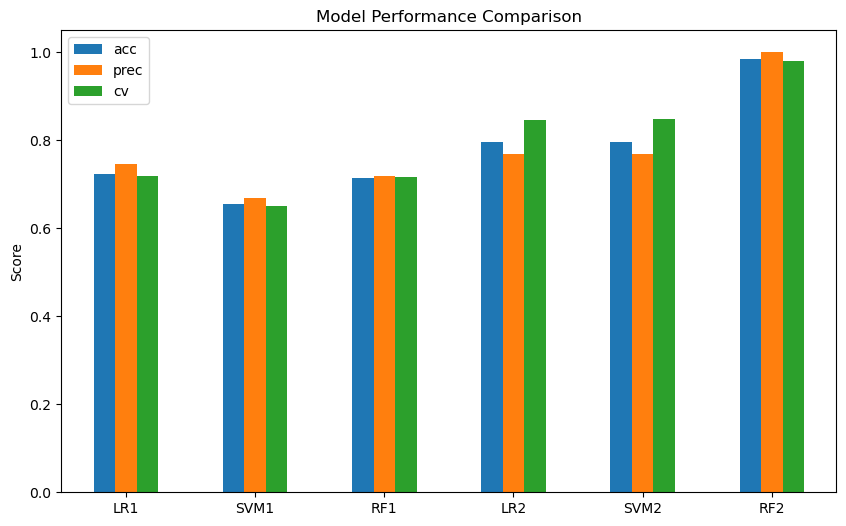

In [26]:
# FINDING BEST MODEL
best_model = performance_df["overall_score"].idxmax()

print("Best Model:", best_model)
# MODEL PERFORMANCE VISUALIZATION
import matplotlib.pyplot as plt

performance_df[["acc","prec","cv"]].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

In [36]:
import pandas as pd
import joblib

# SAVE TRAINED MODELS
joblib.dump(rf1, "rf_model_dataset1.pkl")
joblib.dump(rf2, "rf_model_dataset2.pkl")
joblib.dump(scaler, "scaler.pkl")

# HEART ATTACK RISK PREDICTION FUNCTION
def predict_risk(user_input):
    # Scale input
    user_scaled = scaler.transform(user_input)
    # Probability from both models
    prob1 = rf.predict_proba(user_scaled)[0][1]
    prob2 = rf2.predict_proba(user_scaled)[0][1]
    # Combine predictions
    risk_prob = (prob1 + prob2) / 2
    risk_percent = risk_prob * 100
    # Risk classification
    if risk_percent < 25:
        category = "Low Risk"
    elif risk_percent < 50:
        category = "Medium Risk"
    elif risk_percent < 75:
        category = "High Risk"
    else:
        category = "Extremely Dangerous"

    return risk_percent, category

# FEATURE IMPORTANCE for DATASET - 1
importance1 = rf1.feature_importances_

fi1 = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": importance1
}).sort_values(by="Importance", ascending=False)

print(fi1)

# FEATURE IMPORTANCE for DATASET - 2
importance2 = rf2.feature_importances_

fi2 = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": importance2
}).sort_values(by="Importance", ascending=False)

print(fi2)

        Feature  Importance
0           age    0.309179
4         ap_hi    0.175971
3        weight    0.172267
2        height    0.157043
5         ap_lo    0.087078
6   cholesterol    0.038196
7          gluc    0.016255
1        gender    0.015695
10       active    0.012888
8         smoke    0.008143
9          alco    0.007283
                          Feature  Importance
2                 chest_pain_type    0.130360
11  vessels_colored_by_flourosopy    0.127003
9                         oldpeak    0.123069
12                    thalassemia    0.120611
7                  Max_heart_rate    0.117384
4                     cholestoral    0.083590
0                             age    0.081492
3          resting_blood_pressure    0.074110
8         exercise_induced_angina    0.045653
10                          slope    0.043773
1                             sex    0.026127
6                        rest_ecg    0.018289
5             fasting_blood_sugar    0.008540
